# CS2 Match Data Collection

The goal of this project is to collect and preprocess professional Counter-Strike 2 match data from public esports sources for future analysis. This notebook focuses on collecting match results from S-tier tournaments and preparing the data into an analysis-ready dataset.

## Collecting Match Data from bo3.gg API

I experimented with multiple esports websites and APIs. After testing several sources, I used bo3.gg API endpoints because they returned structured JSON data that could be processed with pandas.

In [1]:
import requests
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

headers = {"User-Agent": "Mozilla/5.0"}

tournaments_url = "https://api.bo3.gg/api/v1/tournaments"

all_tournaments = []

for offset in range(0, 3022, 20):
    params = {"page[offset]": offset, "page[limit]": 20, "sort": "-start_date", "filter[tournaments.discipline_id][eq]": 1, "with": "teams"}
    r = requests.get(tournaments_url, headers=headers, params=params)
    data = r.json()
    results = data["results"]
    if len(results) == 0:
        break
    
    all_tournaments.extend(results)
    time.sleep(0.5)

tournaments_df = pd.DataFrame(all_tournaments)

#tournaments_df.head()

In [2]:
tournaments_df[["id", "name", "slug", "start_date", "end_date", "tier", "prize"]].head()

,id,name,slug,start_date,end_date,tier,prize
0,5631,CCT Europe 2026 Series 16,cct-europe-2026-series-16,2026-12-01T08:00:00.000+00:00,2026-12-13T08:00:00.000+00:00,b,25000.0
1,5630,CCT Europe 2026 Series 15,cct-europe-2026-series-15,2026-11-25T08:00:00.000+00:00,2026-12-07T08:00:00.000+00:00,b,25000.0
2,4226,PGL Major Singapore 2026,pgl-major-singapore-2026,2026-11-25T07:00:00.000+00:00,2026-12-13T21:00:00.000+00:00,s,1250000.0
3,4225,YaLLa Compass UAE 2026,yalla-compass-uae-2026,2026-11-16T07:00:00.000+00:00,2026-11-22T21:00:00.000+00:00,s,600000.0
4,4224,BLAST Rivals Fall 2026,blast-rivals-fall-2026,2026-11-11T07:00:00.000+00:00,2026-11-15T21:00:00.000+00:00,s,1000000.0


In [3]:
tournaments_df["start_date"] = pd.to_datetime(tournaments_df["start_date"], errors="coerce")
tournaments_df["end_date"] = pd.to_datetime(tournaments_df["end_date"], errors="coerce")

today = pd.Timestamp.now(tz="UTC")

# Filter to get s-tier tournament within after 2023 only
s_tier_finished = tournaments_df[
    (tournaments_df["tier"].str.lower() == "s") &
    (tournaments_df["end_date"] < today) &
    (tournaments_df["start_date"] >= "2023-09-01")].copy()

s_tier_finished[["id", "name", "slug", "start_date", "end_date", "prize", "tier"]].head()

,id,name,slug,start_date,end_date,prize,tier
98,4208,CS Asia Championships 2026,cs-asia-championships-2026,2026-05-20 03:00:00+00:00,2026-05-24 11:00:00+00:00,1000000.0,s
107,5108,Intel Extreme Masters Atlanta 2026,intel-extreme-masters-atlanta-2026,2026-05-11 15:30:00+00:00,2026-05-16 22:00:00+00:00,1000000.0,s
119,4207,PGL Astana 2026,pgl-astana-2026,2026-05-09 05:00:00+00:00,2026-05-17 17:00:00+00:00,1600000.0,s
128,4206,BLAST Rivals Spring 2026,blast-rivals-spring-2026,2026-04-29 15:00:00+00:00,2026-05-03 22:30:00+00:00,1000000.0,s
151,4203,YaLLa Compass Qatar 2026,yalla-compass-qatar-2026,2026-04-20 06:00:00+00:00,2026-04-26 20:00:00+00:00,600000.0,s


In [4]:
matches_url = "https://api.bo3.gg/api/v1/matches"

all_matches = []
for tid in s_tier_finished["id"]:
    params = {"filter[matches.tournament_id][eq]": int(tid), "page[limit]": 100, "sort": "start_date"}
    r = requests.get(matches_url, headers=headers, params=params)
    data = r.json()
    results = data.get("results", [])
    all_matches.extend(results)
    time.sleep(0.5)

matches_all_df = pd.json_normalize(all_matches)

matches_all_df.head()

,id,slug,round_id,team1_id,team2_id,winner_team_id,loser_team_id,tournament_id,team1_score,team2_score,...,live_updates.team_2.match_score,live_updates.team_2.economy_level,live_updates.team_2.equipment_value,live_updates.map_name,live_updates.game_ended,live_updates.game_number,live_updates.round_phase,live_updates.round_number,bet_updates.provider,bet_updates.status
0,119817,3dmax-vs-mibr-20-05-2026,36690.0,696.0,755.0,755.0,696.0,4208,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,119816,parivision-vs-liquid-20-05-2026,36690.0,8171.0,790.0,8171.0,790.0,4208,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,119818,the-mongolz-vs-lynn-vision-20-05-2026,36690.0,736.0,476.0,736.0,476.0,4208,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,119819,b8-vs-nip-20-05-2026,36690.0,1539.0,785.0,1539.0,785.0,4208,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,119813,mousesports-vs-tyloo-cs-go-20-05-2026,36689.0,765.0,757.0,757.0,765.0,4208,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Filter the dataset to keep only finished matches and remove rows with missing winner information
matches_clean = matches_all_df[
    (matches_all_df["status"] == "finished") &
    (matches_all_df["winner_team_id"].notna())].copy()

matches_clean[["id", "slug", "tournament_id", "team1_id", "team2_id","winner_team_id", "team1_score", "team2_score",
               "bo_type", "start_date"]].head()

,id,slug,tournament_id,team1_id,team2_id,winner_team_id,team1_score,team2_score,bo_type,start_date
0,119817,3dmax-vs-mibr-20-05-2026,4208,696.0,755.0,755.0,0.0,1.0,1,2026-05-20T03:15:00.000+00:00
1,119816,parivision-vs-liquid-20-05-2026,4208,8171.0,790.0,8171.0,1.0,0.0,1,2026-05-20T03:15:00.000+00:00
2,119818,the-mongolz-vs-lynn-vision-20-05-2026,4208,736.0,476.0,736.0,1.0,0.0,1,2026-05-20T04:20:00.000+00:00
3,119819,b8-vs-nip-20-05-2026,4208,1539.0,785.0,1539.0,1.0,0.0,1,2026-05-20T04:25:00.000+00:00
4,119813,mousesports-vs-tyloo-cs-go-20-05-2026,4208,765.0,757.0,757.0,0.0,1.0,1,2026-05-20T05:15:00.000+00:00


In [6]:
# Convert date columns to datetime format
matches_clean["start_date"] = pd.to_datetime(matches_clean["start_date"], errors="coerce")
matches_clean["end_date"] = pd.to_datetime(matches_clean["end_date"], errors="coerce")

# Convert BO type to readable format
bo_map = {1: "BO1", 3: "BO3", 5: "BO5"}
matches_clean["bo_format"] = matches_clean["bo_type"].map(bo_map)

# Winner
matches_clean["team1_win"] = matches_clean["winner_team_id"] == matches_clean["team1_id"]
matches_clean["team2_win"] = matches_clean["winner_team_id"] == matches_clean["team2_id"]

#Extract team names from slug
matches_clean["match_name"] = (matches_clean["slug"].str.replace(r"-\d{2}-\d{2}-\d{4}$", "", regex=True))  # remove the date suffix from the match slug
split_teams = matches_clean["match_name"].str.split("-vs-", expand=True)
matches_clean["team1_name"] = split_teams[0]
matches_clean["team2_name"] = split_teams[1]

In [7]:
# Remove -cs-go, replace hyphens with spaces,and convert team names to title case.
matches_clean["team1_name"] = (matches_clean["team1_name"].str.replace("-cs-go", "", regex=False).str.replace("-", " ", regex=False).str.title())
matches_clean["team2_name"] = (matches_clean["team2_name"].str.replace("-cs-go", "", regex=False).str.replace("-", " ", regex=False).str.title())
matches_clean[["team1_name", "team2_name"]].head(10)

,team1_name,team2_name
0,3Dmax,Mibr
1,Parivision,Liquid
2,The Mongolz,Lynn Vision
3,B8,Nip
4,Mousesports,Tyloo
5,Legacy Br,Nrg
6,Falcons Esports,Bc Game
7,Pain Gaming,M80
8,Mibr,Parivision
9,The Mongolz,B8


In [8]:
# Create a column containing the winner's team name
matches_clean["winner_name"] = matches_clean.apply(lambda row: row["team1_name"] if row["winner_team_id"] == row["team1_id"]
        else row["team2_name"], axis=1)

matches_clean[["team1_name", "team2_name", "winner_name"]].head(10)

,team1_name,team2_name,winner_name
0,3Dmax,Mibr,Mibr
1,Parivision,Liquid,Parivision
2,The Mongolz,Lynn Vision,The Mongolz
3,B8,Nip,B8
4,Mousesports,Tyloo,Tyloo
5,Legacy Br,Nrg,Legacy Br
6,Falcons Esports,Bc Game,Falcons Esports
7,Pain Gaming,M80,M80
8,Mibr,Parivision,Mibr
9,The Mongolz,B8,B8


In [29]:
# Drop unnescessary and NaN columns
drop_cols = [
    col for col in matches_clean.columns
    if (
        "live_updates" in col
        or "bet_updates" in col
        or "comments" in col
    )]
drop_cols = [
    "prev_match1_id",
    "prev_match2_id",
    "prev_match1_winner",
    "prev_match2_winner",
    "live_coverage_source",
    "points",
    "stars",
    "rating",
    "live_coverage",
    "live_coverage_advantage",
    "discipline_id",
    "team1_new_participant",
    "team2_new_participant"]

drop_cols = [col for col in drop_cols if col in matches_clean.columns]
matches_clean = matches_clean.drop(columns=drop_cols)
matches_clean.shape

(2111, 30)

In [30]:
# Bring highlight columns to the front.
front_cols = [
    "id",
    "team1_name",
    "team2_name",
    "winner_name",
    "team1_score",
    "team2_score",
    "bo_format",
    "start_date",
    "tournament_id"]

remaining_cols = [col for col in matches_clean.columns if col not in front_cols]
matches_clean = matches_clean[front_cols + remaining_cols]

In [31]:
matches_clean.to_csv("cs2_s_tier_matches.csv",index=False)

# Visualization

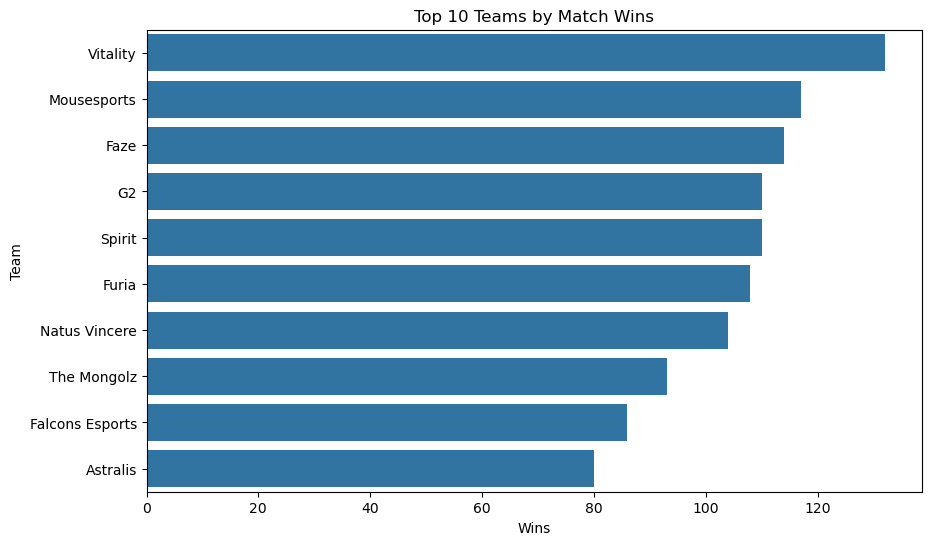

In [27]:
# Top 10 teams have the most win
import matplotlib.pyplot as plt
import seaborn as sns

top_winners = (matches_clean["winner_name"].value_counts().head(10))
plt.figure(figsize=(10,6))
sns.barplot(x=top_winners.values, y=top_winners.index)

plt.title("Top 10 Teams by Match Wins")
plt.xlabel("Wins")
plt.ylabel("Team")
plt.show()

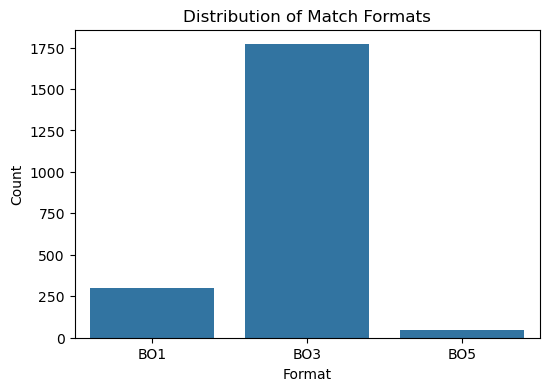

In [33]:
# Number of matched played in each bo format
plt.figure(figsize=(6,4))
sns.countplot(data=matches_clean, x="bo_format")

plt.title("Distribution of Match Formats")
plt.xlabel("Format")
plt.ylabel("Count")
plt.show()

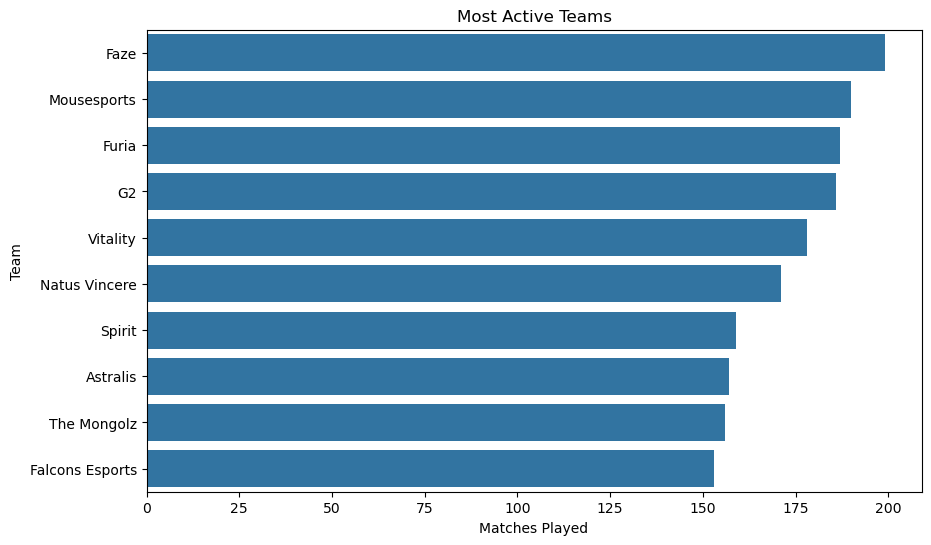

In [40]:
# Find the 10 teams with the most matches played
all_teams = pd.concat([matches_clean["team1_name"], matches_clean["team2_name"]]) # combine all team appearances
top_active = all_teams.value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_active.values, y=top_active.index)

plt.title("Most Active Teams")
plt.xlabel("Matches Played")
plt.ylabel("Team")

plt.show()

In [41]:
team1_df = pd.DataFrame({"team": matches_clean["team1_name"], "opponent": matches_clean["team2_name"],
                         "won": (matches_clean["winner_team_id"] == matches_clean["team1_id"]).astype(int),
                         "bo_format": matches_clean["bo_format"], 
                         "start_date": matches_clean["start_date"]})

team2_df = pd.DataFrame({"team": matches_clean["team2_name"], "opponent": matches_clean["team1_name"], 
                         "won": (matches_clean["winner_team_id"] == matches_clean["team2_id"]).astype(int),
                         "bo_format": matches_clean["bo_format"],
                         "start_date": matches_clean["start_date"]})
team_level_df = pd.concat([team1_df, team2_df], ignore_index=True)

# Calculate team_level win rates and keep only teams with large number of matches
team_stats = (team_level_df.groupby("team").agg(matches_played=("won", "count"), wins=("won", "sum"), winrate=("won", "mean")).reset_index())
team_stats = team_stats[team_stats["matches_played"] >= 20].copy()  # Keep only teams with at least 20 matches
# Then sort by win rate
team_stats = team_stats.sort_values("winrate",ascending=False)

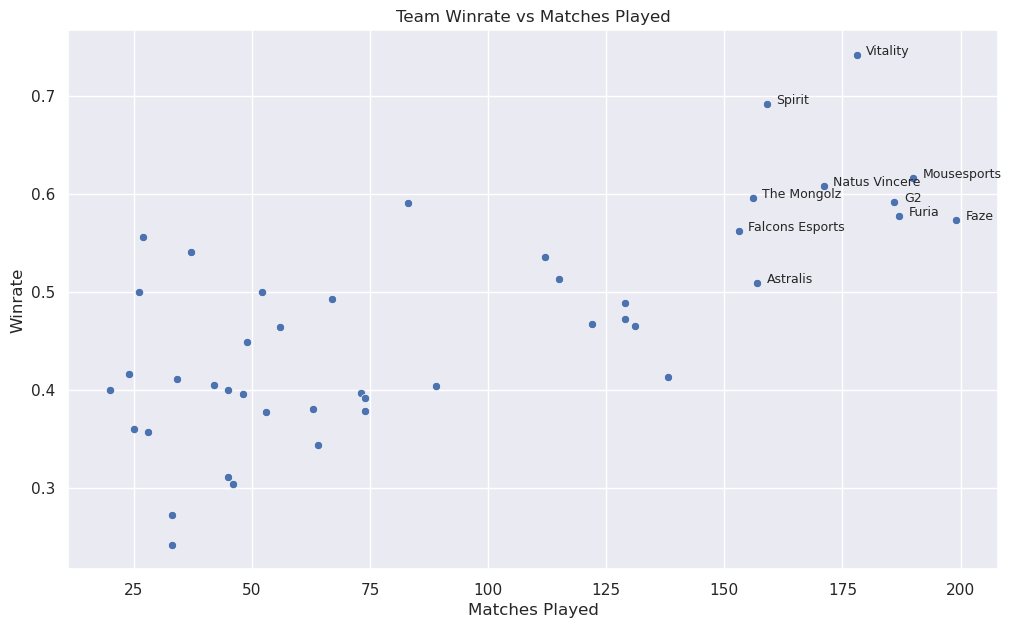

In [31]:
# Winrate of Teams with more than 150 matches only
top_teams = team_stats[team_stats["matches_played"] >= 150]

plt.figure(figsize=(12,7))

sns.set_theme(style="darkgrid")
sns.scatterplot(data=team_stats, x="matches_played", y="winrate")

for _, row in top_teams.iterrows():
    plt.text(row["matches_played"] + 2, row["winrate"], row["team"], fontsize=9)

plt.title("Team Winrate vs Matches Played")
plt.xlabel("Matches Played")
plt.ylabel("Winrate")
plt.show()

Teams with both high winrates and large numbers of matches played appear in the upper-right region of the graph, suggesting sustained competitive dominance across S-tier tournaments. Teams with high winrates but low match counts may reflect smaller sample sizes rather than consistent long-term performance.

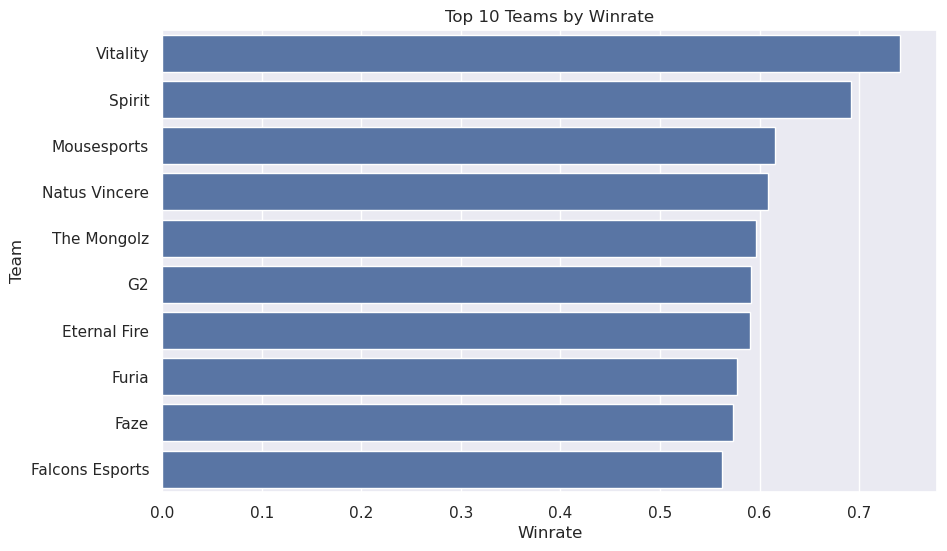

In [32]:
# Top 10 teams have highest winrate
top_winrate = team_stats.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_winrate,
    x="winrate",
    y="team"
)

plt.title("Top 10 Teams by Winrate")
plt.xlabel("Winrate")
plt.ylabel("Team")

plt.show()